## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
Already up to date.


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import os, glob
import pandas as pd
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import roc_auc_score

from Challenge.paths import load_xgboost_cv_folds, XGBOOST_DATAFRAMES
from Challenge.utils import evaluate_recommender
from Challenge.XGBoostNative import XGBoostNativeRecommender, ProgressCallback, EfficientRankerIterator

Running on local — storage at: /home/luigi/RecSys


## **Load Data**

In [4]:
# The columns you identified as highly correlated/redundant
DROP_COLS = [
    'ItemKNN_dice_Score', 'UserKNN_jaccard_Score', 'UserKNN_asymmetric_Score', 
    'UserKNN_asymmetric_RankPosition', 'UserKNN_tversky_Score', 'UserKNN_dice_Score', 
    'UserKNN_dice_RankPosition', 'UserKNN_dice_Recommended', 'EASE_R_Score', 
    'MatrixFactorization_WARP_RankPosition', 'Kurtosis_RankPosition', 
    'Item_Global_Popularity'
]

# The columns that are not features but metadata
META_COLS = ['UserID', 'ItemID', 'Label']
CATEGORICAL_COLS = ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']

INPUT_FILES = sorted(glob.glob(os.path.join(XGBOOST_DATAFRAMES, "ready_for_xgboost", "clean_part_*.parquet")))

print(f"Found {len(INPUT_FILES)} input files.")

Found 10 input files.


In [5]:
iterator = EfficientRankerIterator(
    INPUT_FILES,
    drop_cols=DROP_COLS + META_COLS,
    categorical_cols=CATEGORICAL_COLS
)

dtrain = xgb.QuantileDMatrix(
    iterator, 
    enable_categorical=True
)


--- Resetting Iterator (Starting new pass) ---
[Batch 1/10] Loading: clean_part_0.parquet ... Done. (1.30s) | Rows: 4190859 | Groups: 2710 | RAM Cleanup: 7 objs
[Batch 2/10] Loading: clean_part_1.parquet ... Done. (1.12s) | Rows: 4185342 | Groups: 2710 | RAM Cleanup: 7 objs
[Batch 3/10] Loading: clean_part_2.parquet ... Done. (1.08s) | Rows: 4189441 | Groups: 2710 | RAM Cleanup: 7 objs
[Batch 4/10] Loading: clean_part_3.parquet ... Done. (1.06s) | Rows: 4187034 | Groups: 2710 | RAM Cleanup: 7 objs
[Batch 5/10] Loading: clean_part_4.parquet ... Done. (1.03s) | Rows: 4194806 | Groups: 2710 | RAM Cleanup: 7 objs
[Batch 6/10] Loading: clean_part_5.parquet ... Done. (0.97s) | Rows: 4179287 | Groups: 2709 | RAM Cleanup: 7 objs
[Batch 7/10] Loading: clean_part_6.parquet ... Done. (0.98s) | Rows: 4189899 | Groups: 2709 | RAM Cleanup: 7 objs
[Batch 8/10] Loading: clean_part_7.parquet ... Done. (0.95s) | Rows: 4190561 | Groups: 2709 | RAM Cleanup: 7 objs
[Batch 9/10] Loading: clean_part_8.parqu

In [6]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "validation_data.parquet")

X_val = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
X_val

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/validation_data.parquet


,UserID,ItemID,Label,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,ItemKNN_cosine_Score,ItemKNN_cosine_RankPosition,ItemKNN_cosine_Recommended,ItemKNN_jaccard_Score,...,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score,User_Profile_Len,Item_Global_Popularity
0,0,13,0,0.042611,1293,0,0.209837,546,0,0.152503,...,807.000000,640.260010,0.396104,-1.387824,0.079952,0.072270,0.379061,-1.410258,80,455
1,0,50,0,0.036711,1426,0,0.260275,387,0,0.160119,...,1710.349976,2271.752197,1.605984,0.860943,0.084111,0.087134,1.112715,0.423217,80,392
2,0,56,0,0.031748,1591,0,0.160802,766,0,0.029974,...,1203.199951,1724.353760,2.679983,6.573970,0.084862,0.121599,1.696458,2.612415,80,339
3,0,76,0,0.069863,844,0,0.396849,149,0,0.046681,...,535.250000,538.226318,1.486403,1.452570,0.136666,0.152770,2.242500,5.947872,80,746
4,0,86,0,0.316351,78,0,0.452824,95,0,0.114147,...,259.950012,575.916443,4.315951,18.993521,0.203586,0.128287,0.783605,-0.080525,80,3378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8294894,27094,6896,0,0.018075,2174,0,0.190964,536,0,0.080599,...,1058.349976,1241.071289,1.816220,2.605979,0.154682,0.155793,1.511246,2.464077,250,193
8294895,27094,6920,0,0.029875,1598,0,0.158025,695,0,0.188088,...,582.549988,422.915009,1.092383,0.807492,0.140660,0.080152,0.607600,0.520911,250,319
8294896,27094,6941,0,0.139352,341,0,0.405277,114,0,0.344520,...,210.000000,169.104446,1.361348,1.119403,0.262404,0.122670,-0.301021,-1.537528,250,1488
8294897,27094,6945,0,0.010114,2848,0,0.290307,243,0,0.132695,...,402.950012,598.583374,3.954274,16.615015,0.216858,0.171328,1.195468,0.898166,250,108


In [7]:
_, URM_outer, _ = load_xgboost_cv_folds()
del _

## **Train XG Boost**

In [ ]:
n_estimators   = 50
learning_rate  = 1e-1
reg_alpha      = 1e-1
reg_lambda     = 1e-1
max_depth      = 5
grow_policy    = "depthwise"
objective      = "pairwise"

params = {
    "objective": f"rank:{objective}",   # rank:pairwise
    "learning_rate": learning_rate,
    "reg_alpha": reg_alpha,
    "reg_lambda": reg_lambda,
    "max_depth": max_depth,
    "grow_policy": grow_policy,
    "max_leaves": 0,
    "booster": "gbtree",
    "verbosity": 1,
    "random_state": 42,
    "n_jobs": -1,

    "tree_method": "hist"
}


In [9]:
XGB_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=n_estimators,
    callbacks=[ProgressCallback(n_estimators)]
)

[Training] Tree 50/1

## **Score**

In [10]:
# Evaluate training performance
y_pred_scores = XGB_model.predict(dtrain)
y_train_true = dtrain.get_label()
auc_score = roc_auc_score(y_train_true, y_pred_scores)
print(f"Training AUC Score: {auc_score:.4f}")

Training AUC Score: 0.8008


In [12]:
# Drop cols
X_val = X_val.drop(columns=DROP_COLS)

In [13]:
# Instantiate the recommender with the trained XGB model
recommender_instance = XGBoostNativeRecommender(
    XGB_model=XGB_model,
    df=X_val
)
    
# Evaluate
score = evaluate_recommender(recommender_instance, at=20, URM_validation=URM_outer)
print(f"Validation Score (RECALL@20): {score:.4f}")

Indexing users...


Eval Batches: 100%|██████████| 28/28 [00:07<00:00,  3.90it/s]

Validation Score (RECALL@20): 0.2926


## **Plots**

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

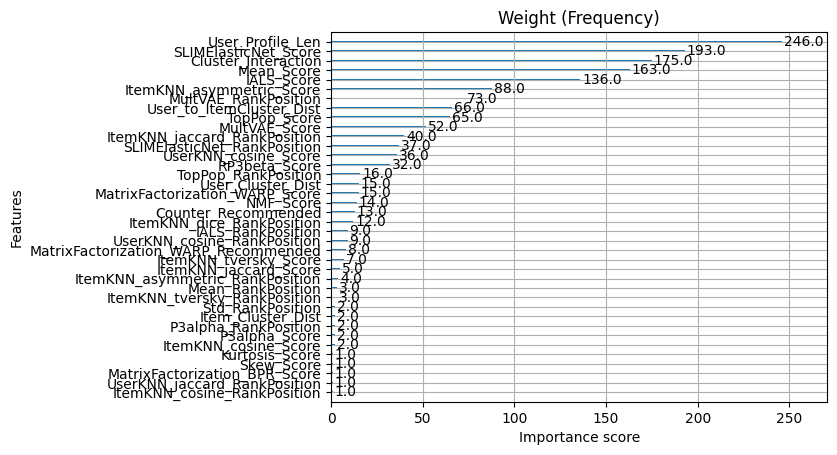

In [14]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

<Axes: title={'center': 'Gain'}, xlabel='Importance score', ylabel='Features'>

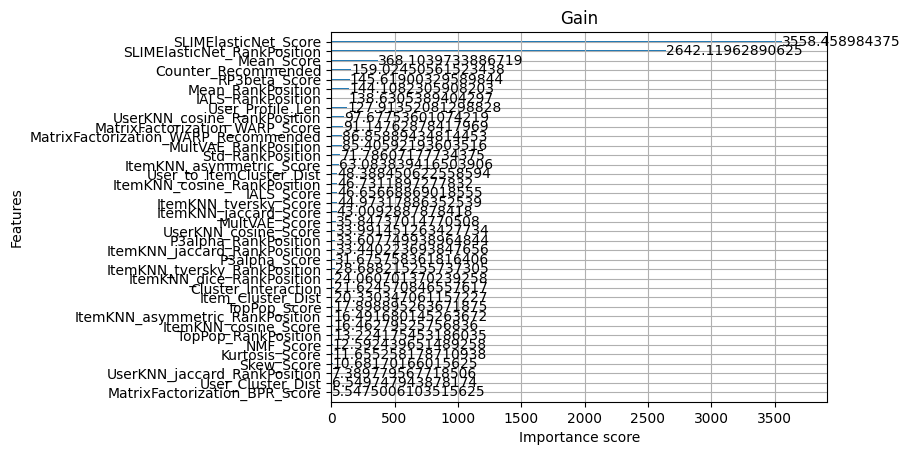

In [15]:
plot_importance(XGB_model, importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='Importance score', ylabel='Features'>

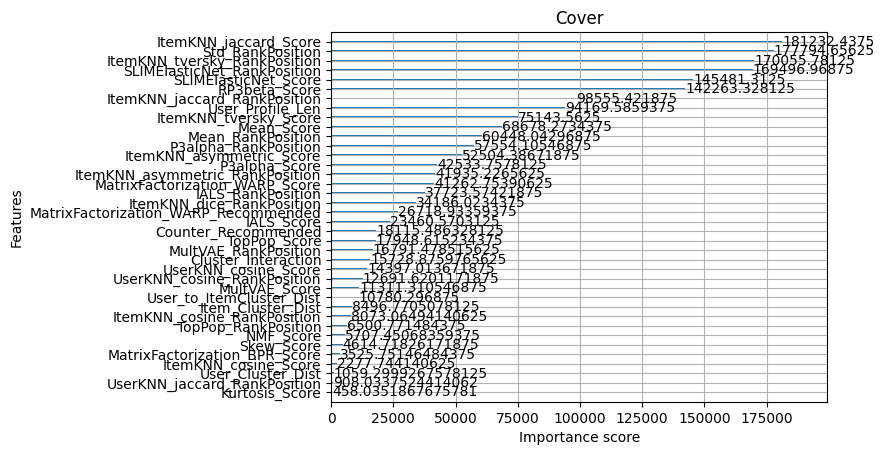

In [16]:
plot_importance(XGB_model, importance_type='cover', title='Cover')

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

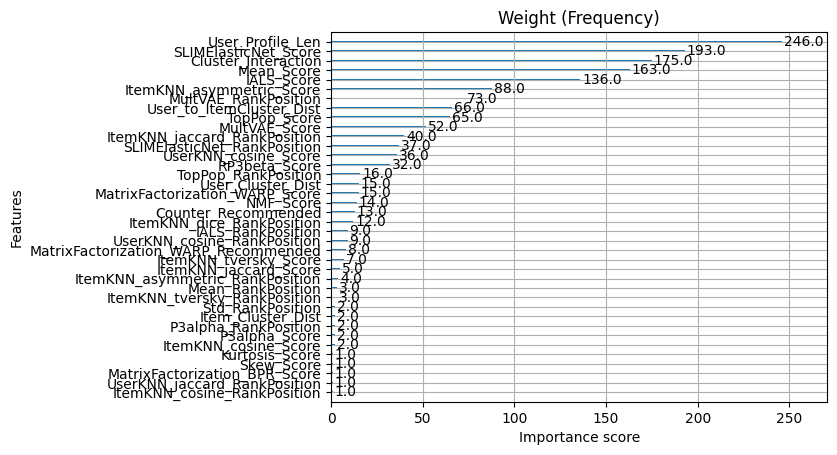

In [17]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')